# CS 195: Natural Language Processing
## Semantic Search with Embeddings

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ericmanley/s26-CS195NLP/blob/main/F4_3_SemanticSearchEmbeddings.ipynb)


## References

[Dot product (Wikipedia)](https://en.wikipedia.org/wiki/Dot_product)

[Cosine similarity (Wikipedia)](https://en.wikipedia.org/wiki/Cosine_similarity)

[Sentence-Transformers documentation](https://www.sbert.net/)

[all-MiniLM-L6-v2 model card](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)



In [1]:
#import sys
#!{sys.executable} -m pip install torch tokenizers sentence-transformers matplotlib

## Let's think more about vectors for a bit

We previously talked about how thing computed by neural network nodes

$$y = w_nx_n+w_{n-1}x_{n-1}+\cdots+w_1x_1+b$$

could be thought of as vector operations 

$$y = \boldsymbol{w} \cdot \boldsymbol{x} + \boldsymbol{b}$$

where we have parameter vector $\boldsymbol{w} = [w_1, w_2, \ldots, w_n]$ and input vector $\boldsymbol{x} = [x_1, x_2, \ldots, x_n]$ and the operation we perform on them is the **dot product**
 


## Embeddings as vectors

We also talked about how the word embeddings we've come up with can be thought of vectors too, and we want to be able to think about how similar two embeddings are.

The dot product is one thing we could use. It more or less tells you how much of one vector *goes in the direction of another* and it is scaled by how long the vectors are. Here's a visualization ChatGPT made for me.

length of v1 = 3.1622776985168457
length of v2 = 4.8166375160217285
length of v3 = 2.8284270763397217
length of v4 = 2.2360680103302
dot(v1, v2) = 13.999999046325684
dot(v1, v3) = 8.0
dot(v1, v4) = -5.0


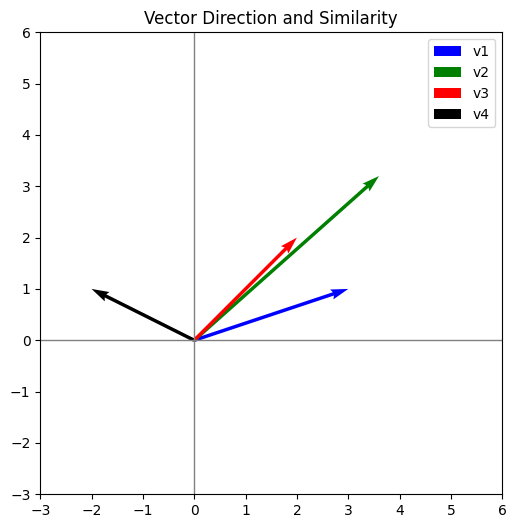

In [2]:
import torch
import matplotlib.pyplot as plt

# Two small 2D examples for intuition
v1 = torch.tensor([3.0, 1.0])
v2 = torch.tensor([3.6, 3.2])
v3 = torch.tensor([2.0, 2.0])
v4 = torch.tensor([-2.0, 1.0])


print('length of v1 =', torch.norm(v1).item())
print('length of v2 =', torch.norm(v2).item())
print('length of v3 =', torch.norm(v3).item())
print('length of v4 =', torch.norm(v4).item())

print('dot(v1, v2) =', torch.dot(v1, v2).item())
print('dot(v1, v3) =', torch.dot(v1, v3).item())
print('dot(v1, v4) =', torch.dot(v1, v4).item())


plt.figure(figsize=(6, 6))
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)
plt.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='blue', label='v1')
plt.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='green', label='v2')
plt.quiver(0, 0, v3[0], v3[1], angles='xy', scale_units='xy', scale=1, color='red', label='v3')
plt.quiver(0, 0, v4[0], v4[1], angles='xy', scale_units='xy', scale=1, label='v4')
plt.xlim(-3, 6)
plt.ylim(-3, 6)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.title('Vector Direction and Similarity')
plt.show()

## Cosine Similarity

For embeddings, the *length* of a vector isn't usually as important as its direction. 
* **direction** often encodes semantic relationships - words with similar meanings appear in the same direction
* **magnitude** is more random or picks up on things like word frequency

So, instead, we often measure similarity by calculating the cosine of the angle between them, which is just their dot product divided by the product of the vector lengths - so it removes the magnitude. If $\theta$ is the angle between two vectors,

$$cos \theta = \frac{\boldsymbol{a} \cdot \boldsymbol{b}}{\| \boldsymbol{a} \| \| \boldsymbol{b} \|}$$

where $\| \boldsymbol{a} \|$ denotes the length of the vector

In [3]:
def cosine(a, b):
    return torch.dot(a, b) / (torch.norm(a) * torch.norm(b))

print('cos(v1, v2) =', cosine(v1, v2).item())
print('cos(v1, v3) =', cosine(v1, v3).item())
print('cos(v1, v4) =', cosine(v1, v4).item())


cos(v1, v2) = 0.9191449880599976
cos(v1, v3) = 0.8944271802902222
cos(v1, v4) = -0.7071067690849304


## Semantic Search

**Semantic Search** is where you look for similarity between a query and set of documents based on embedding similarity. 

**Example query:** *pet animals*

**Example documents:**
* *Dogs and cats are common household pets.*
* *Stocks and bonds are common investment tools.*
* ...
  
We would want the search to return a hit for the first document even though it doesn't share the same words. 
* A traditional term-based search wouldn't find it

In [4]:
documents = [
    "Dogs and cats are common household pets.",
    "Kittens and puppies both need regular veterinary care.",
    "Sharks and whales live in the ocean.",
    "Coral reefs are delicate ocean ecosystems.",
    "Basketball teams practice shooting and defense.",
    "Soccer players train stamina and passing.",
    "Stocks and bonds are common investment tools.",
    "Inflation can affect interest rates and loan costs.",
    "Neural networks learn patterns from data.",
    "Transformers use attention to model language.",
    "Retrieval systems rank documents by relevance.",
    "Embedding vectors can capture semantic similarity."
]

query = "pet animals",



## A possible Semantic Search algorithm

Following what we did last time

1. **Tokenize documents**
2. **Train embeddings** from skip-gram pairs
3. **Pool each document** to one vector (take the average of all the word/token vectors)
4. **Tokenize + pool the query** to one vector
5. **Compute cosine similarities** between query vector and all document vectors
6. **Return documents with highest similarity**

Some problems: 
* We won't see good results from our small corpus - *we should use pre-trained embeddings* from a big corpus
* This kind of pooling (mean pooling) gives us the average over token embeddings, and we lose any benefits from word order - *we should pick a pre-trained embedding model that works on a sentence/document level instead of on each token*

## SentenceTransformer

`SentenceTransformer` is a pretrained model designed to output one embedding vector for an entire sentence (or short paragraph).

It uses a *Transformer* instead of a fully connected neural network like we used for word embeddings. We'll get into the details of Transformers in a few weeks.



## Group Discussion

Take a look at the sentence transformer `all-MiniLM-L6-v2` here: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

Be prepared to share anything interesting you find out about this model.

## Example

first load the SentenceTransformer and then create embeddings for documents and query.

In [5]:
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

documents = [
    "Dogs and cats are common household pets.",
    "Kittens and puppies both need regular veterinary care.",
    "Sharks and whales live in the ocean.",
    "Coral reefs are delicate ocean ecosystems.",
    "Basketball teams practice shooting and defense.",
    "Soccer players train stamina and passing.",
    "Stocks and bonds are common investment tools.",
    "Inflation can affect interest rates and loan costs.",
    "Neural networks learn patterns from data.",
    "Transformers use attention to model language.",
    "Retrieval systems rank documents by relevance.",
    "Embedding vectors can capture semantic similarity."
]

query = "pet animals"

doc_embeddings = st_model.encode(documents, convert_to_tensor=True)
query_embedding = st_model.encode(query, convert_to_tensor=True)

print(query_embedding)



tensor([-5.9698e-02,  4.1905e-02, -3.8638e-02, -2.0284e-02,  2.0404e-02,
        -1.0482e-02,  3.3632e-02, -4.5974e-02, -1.9016e-03, -1.1703e-02,
         4.5572e-02, -1.2596e-01, -2.9910e-02,  5.9056e-02, -2.9956e-02,
         9.7475e-02, -1.0670e-01, -2.0398e-02, -2.8666e-02,  9.0365e-02,
         2.0174e-02,  8.0510e-02, -9.0589e-02, -3.3545e-02, -1.0401e-01,
         3.7460e-03,  5.5993e-02,  8.8608e-03, -5.8143e-02,  1.6285e-02,
        -3.9777e-02,  1.1242e-01,  5.0407e-02, -7.7803e-02,  4.5129e-02,
         8.7806e-02, -1.1769e-02, -6.0621e-02,  2.3501e-02,  7.7471e-02,
        -9.2567e-02, -6.6909e-02,  7.0283e-02,  5.2921e-02,  3.5578e-03,
        -1.0523e-01, -2.3405e-02, -2.6250e-02,  2.2371e-03,  5.4953e-02,
        -8.5974e-02, -7.0779e-02, -3.8150e-02, -3.5362e-02,  1.2429e-02,
        -3.0539e-02, -1.0068e-01,  8.4882e-03,  2.2519e-02, -9.4907e-02,
         8.6758e-02,  2.2139e-02,  4.8702e-02, -9.7700e-03,  5.2200e-02,
         1.7747e-02,  8.0632e-03,  3.8744e-02,  1.2

Calulating the cosine similarity between the query and each document

In [6]:
def cosine(a, b):
    return torch.dot(a, b) / (torch.norm(a) * torch.norm(b))

print("Query:", query)

for d_idx in range(len(documents)):
    doc_sim_score = cosine(query_embedding, doc_embeddings[d_idx])
    print(doc_sim_score.item(), documents[d_idx])
    

Query: marine life in sea water
0.06869319081306458 Dogs and cats are common household pets.
0.05226024240255356 Kittens and puppies both need regular veterinary care.
0.614867091178894 Sharks and whales live in the ocean.
0.49226951599121094 Coral reefs are delicate ocean ecosystems.
-0.0788898691534996 Basketball teams practice shooting and defense.
-0.02471310831606388 Soccer players train stamina and passing.
0.007705375552177429 Stocks and bonds are common investment tools.
0.0020838447380810976 Inflation can affect interest rates and loan costs.
0.04911409318447113 Neural networks learn patterns from data.
-0.040683403611183167 Transformers use attention to model language.
0.03370220214128494 Retrieval systems rank documents by relevance.
0.03626658767461777 Embedding vectors can capture semantic similarity.


## Group Exercise

Try running with these queries
* marine life in sea water
* how to invest money
* models for natural language

Discuss how well the model performs for each


## Practice with a larger dataset

I have a json file with course descriptions from Fall 2025 (sorry, I haven't had time to scrape the schedule for next semester yet!)

Here are a couple of ways you can load the data into your notebook

In [7]:
# load directly from github using the requests library
import requests
import json

response = requests.get("https://raw.githubusercontent.com/ericmanley/S26-CS195NLP/refs/heads/main/data/f25_course_information.json")
data = json.loads(response.text)

In [8]:
# load it as a local file - maybe you need to put it in your Google Drive folder first if you are using Colab
import json

with open("data/f25_course_information.json") as datafile:
    data = json.load(datafile)

Let's look at a sample of the data

In [9]:
for d in data[:3]:
    print(d)

{'id': 213644, 'term': 'Fall 2025', 'course_number': 'ACCT 041', 'subject': 'Accounting', 'title': 'INTRODUCTION TO FINANCIAL ACCOUNTING', 'course_search_url': 'https://catalog.drake.edu/course-search/?details&srcdb=2024&code=ACCT%20041', 'prereq': 'Prerequisite(s): None', 'description': '\n\n    The elements of the financial statements, accounting for deferrals, the double-entry accounting system, internal control and cash, receivables and payables, inventory, operational assets, long-term debt, equity transactions, income measurement, and comprehensive treatment of the balance sheet, the income statement and the statement of cash flows.  Financial statement analysis will be integrated throughout the course.\n    \n\n', 'credit_hours': None, 'faculty': ['Joyce Njoroge'], 'attributes': ['Critical Thinking'], 'location': ['ALIB 0010'], 'times': ['Monday, Wednesday 0930-1045'], 'filename': 'course_213644.json'}
{'id': 214670, 'term': 'Fall 2025', 'course_number': 'ACCT 041', 'subject': '

## Applied Exploration

Perform semantic search on the course information dataset, returning the top 3 courses with course descriptions matching a query (like "Neural Network"). You might find the `torch.topk` function useful: https://docs.pytorch.org/docs/stable/generated/torch.topk.html

* Test your approach out on three queries of your choosing
* Describe the results you're getting. Does it seem to be matching the best courses for your queries?
